# Modelling

## Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import torch
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scripts.hourly_forecasting.data_preparation.data_pipeline import prepare_data_forecasting
from scripts.hourly_forecasting.data_preparation.feature_engineering import construct_features, discard_features
from scripts.hourly_forecasting.models.models import NaiveSimilarDay

## Load and process data

In [3]:
data_path = "../../../data/Hourly_Electricity_Demand_Gen_Weather_Spain/{}.csv";

energy_data_path = data_path.format("energy_dataset");
weather_data_path = data_path.format("weather_features");

energy_data = pd.read_csv(energy_data_path);
weather_data = pd.read_csv(weather_data_path);

data = prepare_data_forecasting(energy_data, weather_data);
data = construct_features(data);
data = discard_features(data);

In [4]:
pd.set_option("display.max_columns", 100);

## Benchmarks

### Naive similar day modelling

In [5]:
data.iloc[int(np.round(data.shape[0] * 0.7)):].shape[0] / data.shape[0] * 100

29.99942961441935

In [6]:
NaiveSimilarDay.initial_data_point(data)

Timestamp('2015-01-12 00:00:00+0000', tz='UTC')

In [7]:
naive_model = NaiveSimilarDay(data.ffill());
naive_model.forecast("2015-01-12")

2015-01-12 00:00:00+00:00    64.89
2015-01-12 01:00:00+00:00    60.91
2015-01-12 02:00:00+00:00    59.68
2015-01-12 03:00:00+00:00    58.04
2015-01-12 04:00:00+00:00    59.57
                             ...  
2018-12-31 18:00:00+00:00    75.30
2018-12-31 19:00:00+00:00    74.95
2018-12-31 20:00:00+00:00    73.16
2018-12-31 21:00:00+00:00    70.39
2018-12-31 22:00:00+00:00    70.20
Name: price actual, Length: 34799, dtype: float64

In [8]:
NaiveSimilarDay.initial_data_point(data.iloc[int(np.round(data.shape[0] * 0.7)):])

Timestamp('2017-10-30 00:00:00+0000', tz='UTC')

In [9]:
naive_model = NaiveSimilarDay(data.ffill().iloc[int(np.round(data.shape[0] * 0.7)):]);
forecasts = naive_model.forecast("2017-10-30");

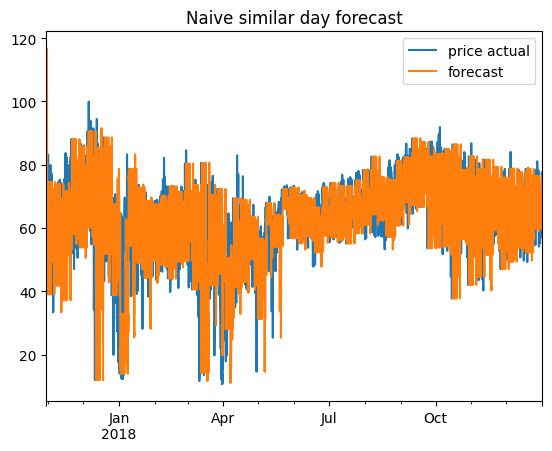

In [10]:
pd.concat([data["price actual"].loc["2017-10-30":], forecasts.rename("forecast")], axis=1).plot(kind="line", title="Naive similar day forecast");

In [15]:
benchmark_mse = mean_squared_error(data["price actual"].loc["2017-10-30":], forecasts);
benchmark_mae = mean_absolute_error(data["price actual"].loc["2017-10-30":], forecasts);

print("MSE: {:.3f} €/MWh**2".format(benchmark_mse));
print("RMSE: {:.3f} €/MWh".format(np.sqrt(benchmark_mse)));
print("MAE: {:.3f} €/MWh".format(benchmark_mae));

MSE: 93.596 €/MWh**2
RMSE: 9.675 €/MWh
MAE: 6.190 €/MWh


## SARIMAX modelling

In [23]:
arima = sm.tsa.statespace.SARIMAX(data["price actual"].loc[:"2017-10-29"], order=(24, 1, 24));

c:\Users\ml4\anaconda3\envs\timeseries\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\ml4\anaconda3\envs\timeseries\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [24]:
arima_res = arima.fit();

c:\Users\ml4\anaconda3\envs\timeseries\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\ml4\anaconda3\envs\timeseries\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\ml4\anaconda3\envs\timeseries\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [25]:
arima_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           price actual   No. Observations:                24793
Model:             SARIMAX(24, 1, 24)   Log Likelihood              -56067.004
Date:                Sat, 12 Jul 2025   AIC                         112232.008
Time:                        18:37:16   BIC                         112629.803
Sample:                    12-31-2014   HQIC                        112360.813
                         - 10-29-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0116      0.009     -1.360      0.174      -0.028       0.005
ar.L2          0.0142      0.008      1.740      0.082      -0.002       0.030
ar.L3         -0.0795      0.008     -9.715      0.000      -0.095      -0.063
ar.L4          0.0215      0.008      2.744      0.006       0.006       0.037
ar.L5         -0.0717      0.008     -9.353      0.000      -0.087      -0.057
ar.L6         -0.0145      0.008     -1.919      0.055      -0.029       0.000
ar.L7         -0.0048      0.007     -0.650      0.515      -0.019       0.010
ar.L8         -0.0664      0.008     -8.847      0.000      -0.081      -0.052
ar.L9          0.0178      0.007      2.493      0.013       0.004       0.032
ar.L10        -0.0790      0.007    -10.783      0.000      -0.093      -0.065
ar.L11         0.0094      0.007      1.333      0.182      -0.004       0.023
ar.L12        -0.0383      0.007     -5.340      0.000      -0.052      -0.024
ar.L13        -0.0383      0.007     -5.258      0.000      -0.053      -0.024
ar.L14         0.0143      0.007      1.956      0.051   -3.23e-05       0.029
ar.L15        -0.0977      0.007    -13.521      0.000      -0.112      -0.084
ar.L16         0.0377      0.007      5.242      0.000       0.024       0.052
ar.L17        -0.0602      0.007     -8.216      0.000      -0.075      -0.046
ar.L18        -0.0226      0.007     -3.067      0.002      -0.037      -0.008
ar.L19        -0.0017      0.007     -0.233      0.816      -0.016       0.013
ar.L20        -0.0870      0.007    -11.814      0.000      -0.101      -0.073
ar.L21         0.0335      0.007      4.561      0.000       0.019       0.048
ar.L22        -0.0809      0.007    -10.963      0.000      -0.095      -0.066
ar.L23         0.0465      0.008      6.116      0.000       0.032       0.061
ar.L24         0.8894      0.008    115.287      0.000       0.874       0.904
ma.L1          0.0456      0.010      4.473      0.000       0.026       0.066
ma.L2         -0.0636      0.009     -6.703      0.000      -0.082      -0.045
ma.L3          0.0351      0.010      3.602      0.000       0.016       0.054
ma.L4         -0.0717      0.009     -7.951      0.000      -0.089      -0.054
ma.L5          0.0234      0.009      2.548      0.011       0.005       0.041
ma.L6         -0.0411      0.009     -4.622      0.000      -0.059      -0.024
ma.L7         -0.0574      0.009     -6.382      0.000      -0.075      -0.040
ma.L8          0.0436      0.009      4.903      0.000       0.026       0.061
ma.L9         -0.0389      0.009     -4.356      0.000      -0.056      -0.021
ma.L10         0.0716      0.009      8.134      0.000       0.054       0.089
ma.L11        -0.0189      0.009     -2.201      0.028      -0.036      -0.002
ma.L12        -0.0057      0.009     -0.660      0.509      -0.022       0.011
ma.L13         0.0010      0.009      0.121      0.904      -0.016       0.018
ma.L14        -0.0640      0.009     -7.076      0.000      -0.082      -0.046
ma

In [30]:
data.loc["2017-10-30":].shape

(10271, 85)

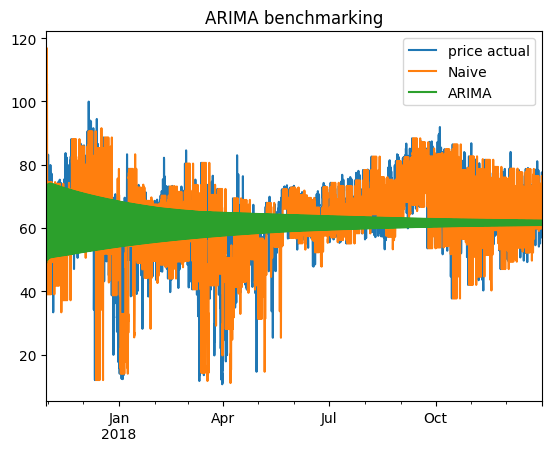

In [35]:
arima_forecasts_recursive = arima_res.forecast(10271);
pd.concat([data["price actual"].loc["2017-10-30":], forecasts.rename("Naive"), arima_forecasts_recursive.rename("ARIMA")], axis=1).plot(kind="line", title="ARIMA benchmarking");

In [38]:
arima_model = sm.tsa.statespace.SARIMAX(data["price actual"], order=(24, 1, 24));
arima_res_proper = arima_model.filter(arima_res.params);

c:\Users\ml4\anaconda3\envs\timeseries\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\ml4\anaconda3\envs\timeseries\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [39]:
arima_res_1_step_ahead = arima_res_proper.predict();

In [42]:
arima_res_1_step_ahead.loc["2017-10-30":]

2017-10-30 00:00:00+00:00    50.774449
2017-10-30 01:00:00+00:00    45.474284
2017-10-30 02:00:00+00:00    41.720837
2017-10-30 03:00:00+00:00    40.621625
2017-10-30 04:00:00+00:00    42.933113
                               ...    
2018-12-31 18:00:00+00:00    78.159970
2018-12-31 19:00:00+00:00    76.439717
2018-12-31 20:00:00+00:00    74.815530
2018-12-31 21:00:00+00:00    72.146668
2018-12-31 22:00:00+00:00    68.229362
Freq: h, Name: predicted_mean, Length: 10271, dtype: float64

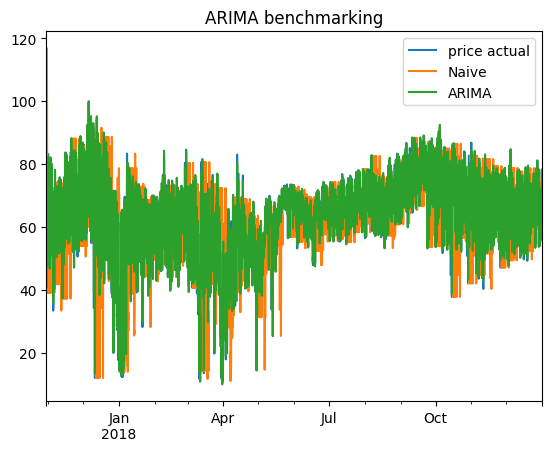

In [47]:
pd.concat([data["price actual"].loc["2017-10-30":], forecasts.rename("Naive"), arima_res_1_step_ahead.loc["2017-10-30":].rename("ARIMA")], axis=1).plot(kind="line", title="ARIMA benchmarking");

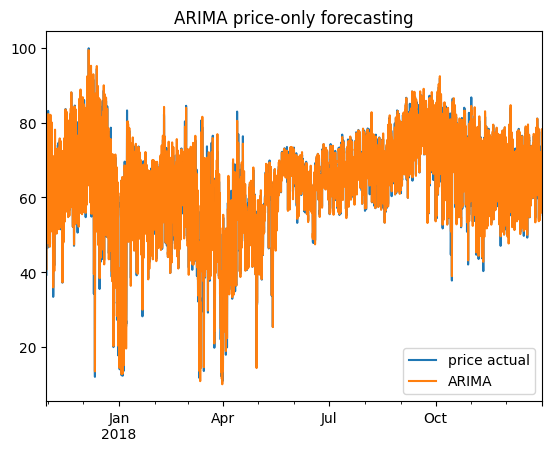

In [49]:
pd.concat([data["price actual"].loc["2017-10-30":], arima_res_1_step_ahead.rename("ARIMA").loc["2017-10-30":]], axis=1).plot(kind="line", title="ARIMA price-only forecasting");

In [50]:
arima_mse = mean_squared_error(data["price actual"].loc["2017-10-30":], arima_res_1_step_ahead.loc["2017-10-30":]);
arima_mae = mean_absolute_error(data["price actual"].loc["2017-10-30":], arima_res_1_step_ahead.loc["2017-10-30":]);

print("MSE: {:.3f} €/MWh**2".format(arima_mse));
print("RMSE: {:.3f} €/MWh".format(np.sqrt(arima_mse)));
print("MAE: {:.3f} €/MWh".format(arima_mae));

MSE: 5.351 €/MWh**2
RMSE: 2.313 €/MWh
MAE: 1.598 €/MWh


## Deep Learning time series modelling